In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df=pd.read_csv("C:\\Users\\LENOVO\\OneDrive\\Desktop\\Machine learning project\\gurgaon_properties_cleaned_v2.xls")

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet ar...,3,3,2,6.0,West,Relatively New,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up...,4,6,3+,15.0,East,Relatively New,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,flat,signature global park,sohna road,0.95,7846.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet ar...,3,2,3+,1.0,NaN,Relatively New,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,house,nirvana cedar crest,sector 50,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,4.0,North-East,New Property,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3,3,2,2.0,North-East,Relatively New,1578.0,NaN,NaN,0,0,0,1,0,0,102


In [5]:
df.shape

(3803, 23)

In [11]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

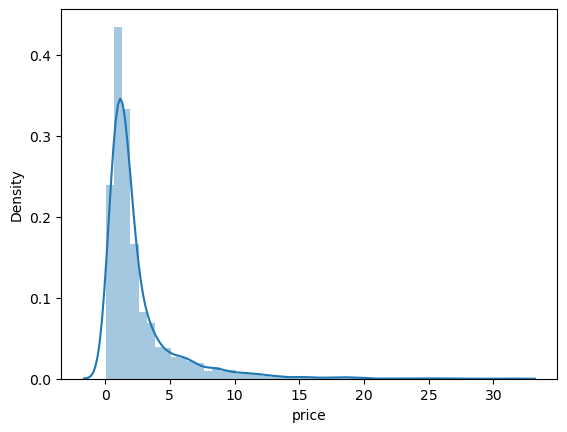

In [13]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

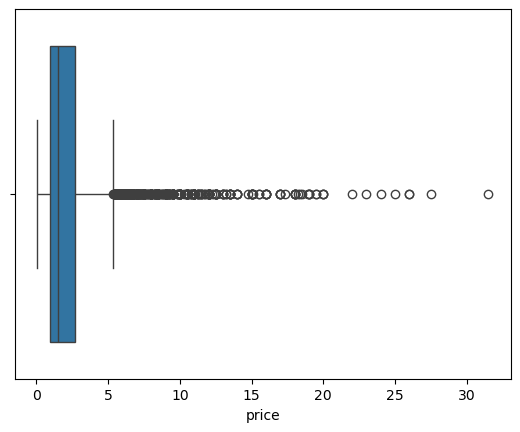

In [15]:
sns.boxplot(x=df['price'])

In [17]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(432,
 count    432.000000
 mean       9.196157
 std        4.061291
 min        5.350000
 25%        6.400000
 50%        8.000000
 75%       10.607500
 max       31.500000
 Name: price, dtype: float64)

In [19]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2922,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,0,1,0,1,0,2,74
281,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,0,0,1,42
80,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,0,0,0,0,0,1,72
1201,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,0,0,0,0,0,1,138
3798,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,0,0
2876,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,0,1,0,1,0,1,122
2542,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,0,0,0,0,0,1,145
1038,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,1,1,0,54
1333,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,0,0,2,97
3468,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,0,0,0,0,1,31


In [21]:
# price _sqft

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

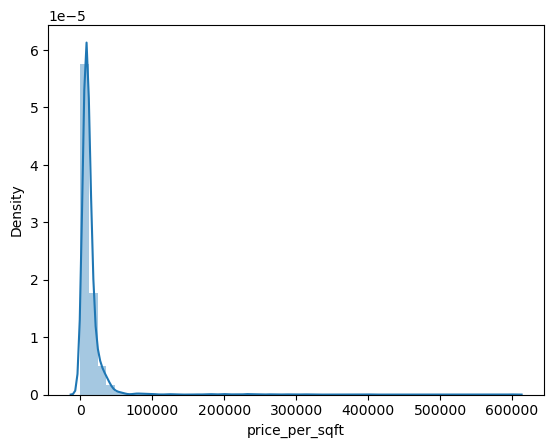

In [23]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

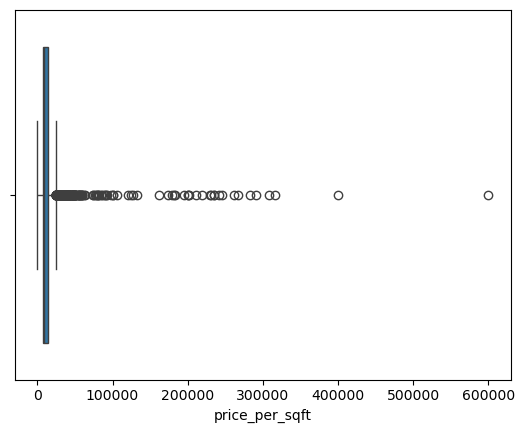

In [25]:
sns.boxplot(x=df['price_per_sqft'])

In [27]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(367,
 count       367.000000
 mean      52115.435967
 std       60746.225927
 min       24202.000000
 25%       27778.000000
 50%       33333.000000
 75%       41790.000000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [29]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [31]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [33]:
outliers_sqft['price_per_sqft'].describe()

count      367.000000
mean     29160.735695
std      12308.413881
min       2689.000000
25%      25051.500000
50%      29630.000000
75%      35489.000000
max      82540.000000
Name: price_per_sqft, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

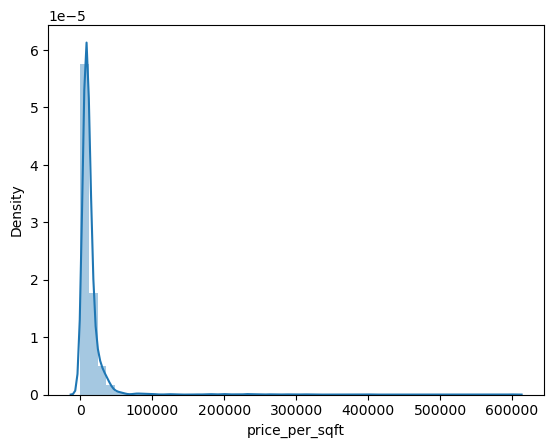

In [35]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

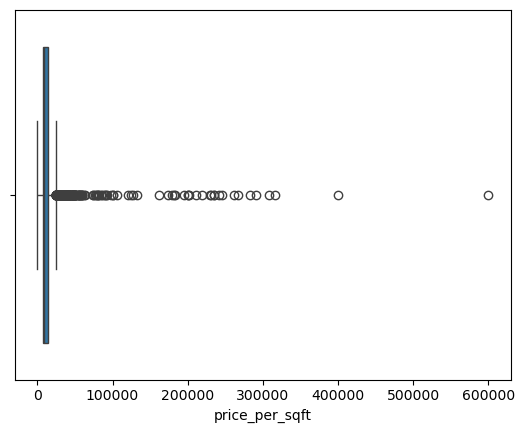

In [37]:
sns.boxplot(x=df['price_per_sqft'])

In [39]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
60,house,rk excelo,sector 12,0.60,120000.0,50.0,Plot area 50(4.65 sq.m.)Built Up area: 30 sq.f...,5,3,2,3.0,North,Moderately Old,NaN,30.0,15.0,0,1,0,1,0,0,0
76,house,independent,sector 105,0.55,98214.0,56.0,Built Up area: 56 (5.2 sq.m.),4,4,0,2.0,NaN,Undefined,NaN,56.0,NaN,0,1,0,0,0,0,0
80,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,0,0,0,0,0,1,72
205,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,1,0,0,0,0,0,0
277,house,independent,sector 54,3.75,234375.0,160.0,Plot area 160(14.86 sq.m.),4,4,3,3.0,East,Moderately Old,NaN,160.0,NaN,0,0,0,0,0,1,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3687,house,unitech nirvana birch court,sector 50,7.10,283333.0,251.0,Plot area 240(22.3 sq.m.),3,3,3,1.0,East,Moderately Old,NaN,240.0,NaN,0,0,0,0,1,0,49
3728,house,unitech uniworld resorts,sector 33,10.00,181818.0,550.0,Plot area 550(51.1 sq.m.),5,6,3,4.0,North-East,New Property,NaN,550.0,NaN,0,1,1,1,0,0,26
3756,house,independent,sector 4,0.61,100000.0,61.0,Plot area 61(5.67 sq.m.),2,2,2,2.0,South-East,Moderately Old,NaN,61.0,NaN,0,0,0,0,0,0,14
3794,house,independent,sector 13,0.50,90909.0,55.0,Plot area 55(5.11 sq.m.),12,4,3,4.0,NaN,Old Property,NaN,55.0,NaN,1,1,1,1,0,0,15


In [41]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

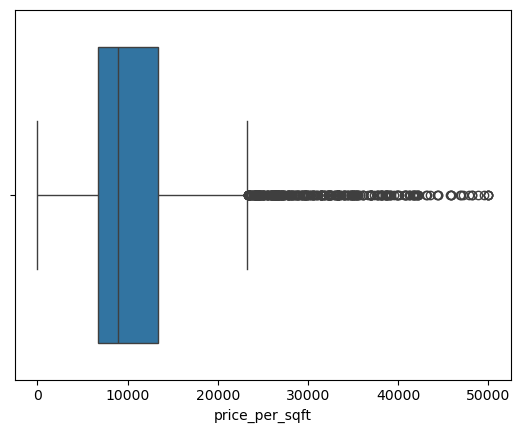

In [43]:
sns.boxplot(x=df['price_per_sqft'])

In [45]:
#Area

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

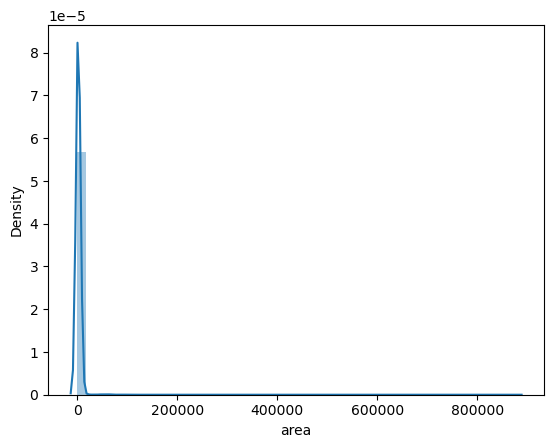

In [47]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

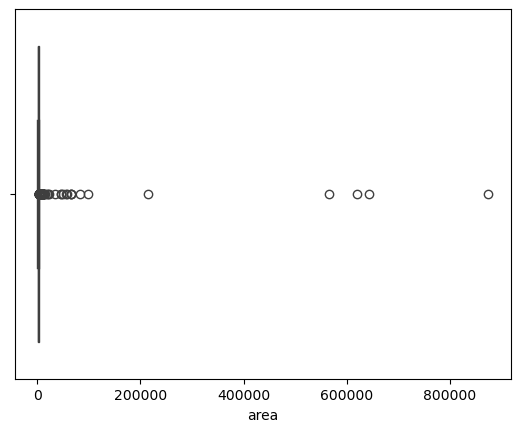

In [49]:
sns.boxplot(x=df['area'])

In [51]:
df['area'].describe()

count      3722.000000
mean       2883.165234
std       22973.272943
min          72.000000
25%        1250.000000
50%        1735.000000
75%        2300.000000
max      875000.000000
Name: area, dtype: float64

In [53]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
346,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,0,0,0,0,0,1,0
2044,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,0,65
2082,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,44
2524,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,2,44
3712,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,76


In [55]:
df = df[df['area'] < 100000]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

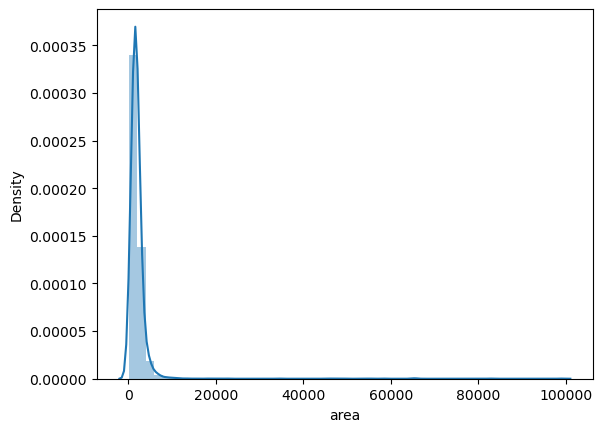

In [57]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

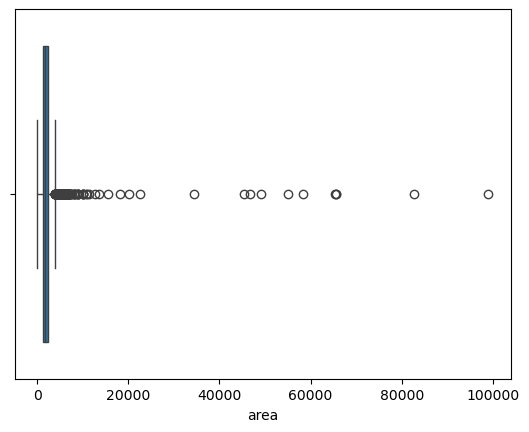

In [59]:
sns.boxplot(x=df['area'])

In [61]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3574,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,0,1,0,1,60
701,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,1,0,0,0,7
3739,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
1082,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
3058,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,1,0,0,1,0,0
3473,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
2964,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
51,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
1407,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,0,0,0,1,109
2440,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [63]:
df.drop(index=[3574,3739,1082,3473,2964,51,2440,3665,2486], inplace=True)

In [65]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
701,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,1,0,0,0,7
3058,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,1,0,0,1,0,0
1407,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,0,0,0,1,109
2840,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,0,0,0,0,1,61
1653,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,NaN,2850.0,2250.00,0,1,0,0,0,1,123
2985,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.00,1,0,0,1,1,1,44
780,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,NaN,2160.0,1720.00,0,0,0,0,0,0,160
982,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55
281,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,0,0,1,42
1845,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.00,0,1,0,0,0,0,60


In [67]:
df.loc[701,'area'] = 115*9
df.loc[3058,'area'] = 7250
df.loc[1407,'area'] = 5800
df.loc[2840,'area'] = 2660
df.loc[1653,'area'] = 2850
df.loc[2985,'area'] = 1812
df.loc[780,'area'] = 2160
df.loc[982,'area'] = 1175

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

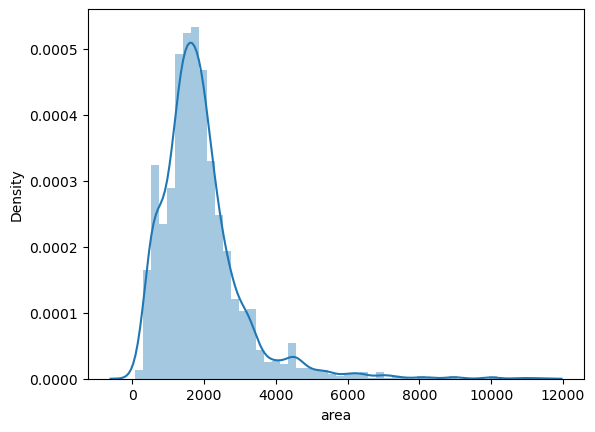

In [69]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

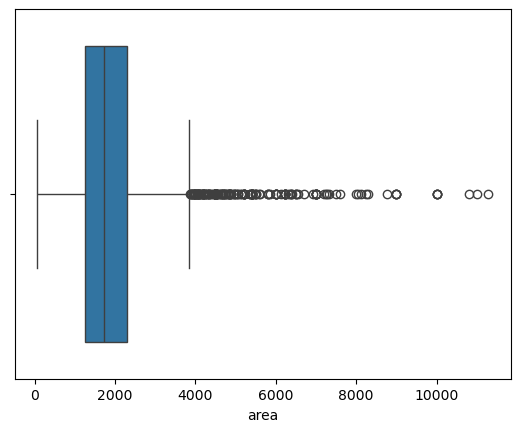

In [71]:
sns.boxplot(x=df['area'])

In [73]:
df['area'].describe()

count     3708.000000
mean      1905.728155
std       1161.227525
min         72.000000
25%       1245.000000
50%       1730.000000
75%       2290.000000
max      11286.000000
Name: area, dtype: float64

In [77]:
#BedRoom

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

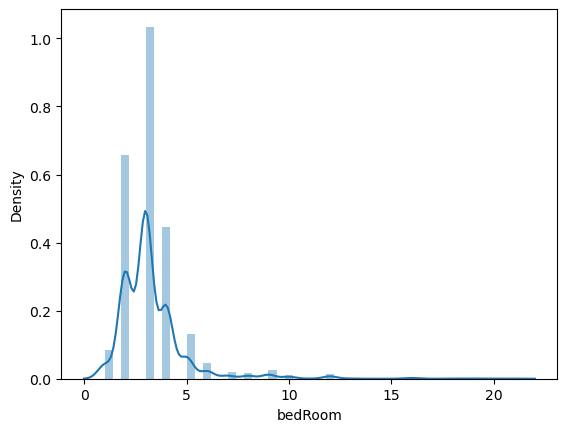

In [79]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

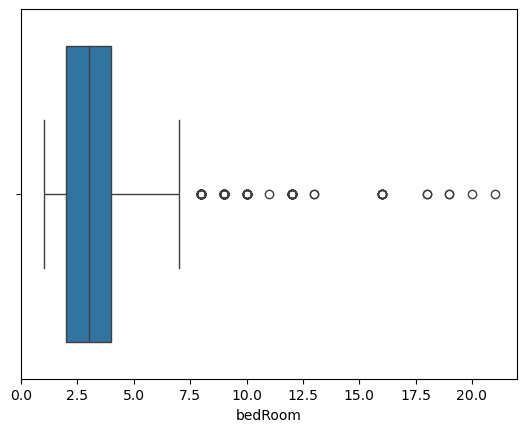

In [81]:
sns.boxplot(x=df['bedRoom'])

In [83]:
df['bedRoom'].describe()

count    3708.000000
mean        3.278587
std         1.752967
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [85]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3742,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,1,0,0,0,0,2,49
1850,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,0,0,0,0,2,22
3731,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,0,1,0,0,0,0,68
3055,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,0,1,0,0,74
1081,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,0,2,57
598,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,0,0,0,0,2,70
3468,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,0,0,0,0,1,31
2515,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.0,NaN,0,0,0,1,0,1,49
2381,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,New Property,NaN,2700.0,NaN,0,0,0,0,0,1,49
1930,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,0,1,0,0,0,0,41


In [87]:
df = df[df['bedRoom'] <= 10]

In [89]:
df.shape

(3670, 23)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

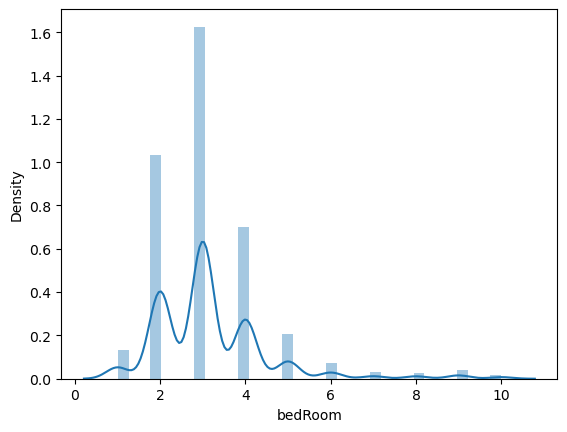

In [91]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

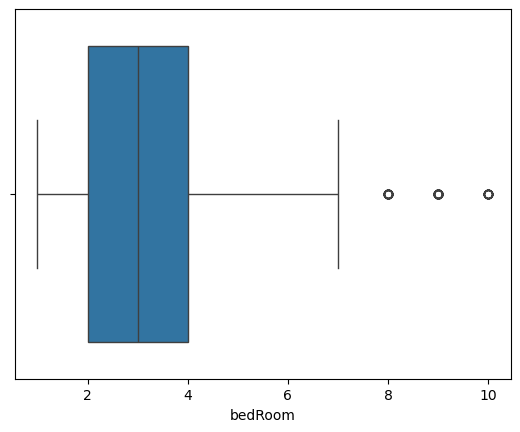

In [93]:
sns.boxplot(x=df['bedRoom'])

In [95]:
df['bedRoom'].describe()

count    3670.000000
mean        3.168665
std         1.358437
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

In [97]:
#bathroom

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

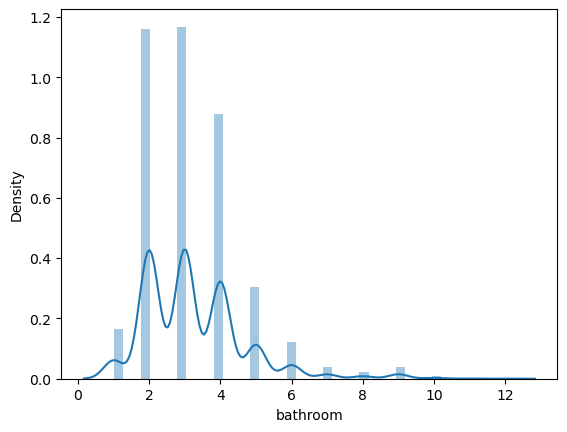

In [99]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

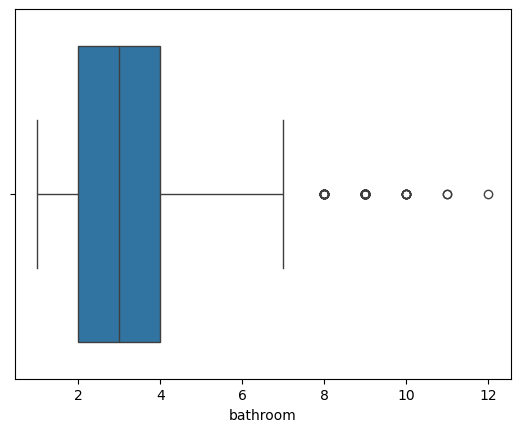

In [101]:
sns.boxplot(x=df['bathroom'])

In [103]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2995,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,1,1,0,0,0,1,146
1494,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,0,0,1,38
3051,house,independent,sector 24,11.00,28898.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,0,0,0,0,1,1,39


In [105]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet ar...,3,3,2,6.0,West,Relatively New,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up...,4,6,3+,15.0,East,Relatively New,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,flat,signature global park,sohna road,0.95,7846.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet ar...,3,2,3+,1.0,NaN,Relatively New,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,house,nirvana cedar crest,sector 50,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,4.0,North-East,New Property,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3,3,2,2.0,North-East,Relatively New,1578.0,NaN,NaN,0,0,0,1,0,0,102


In [107]:
#super built up area

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

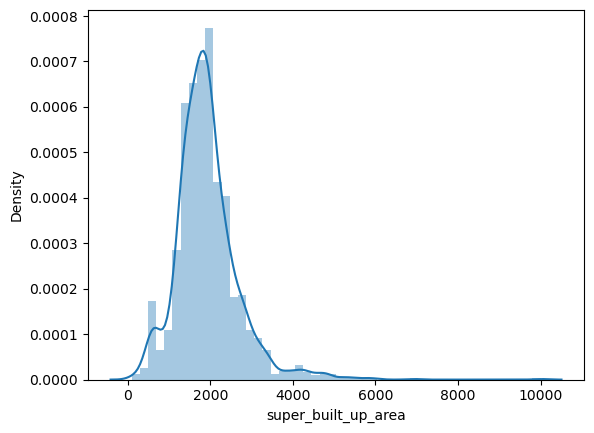

In [109]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

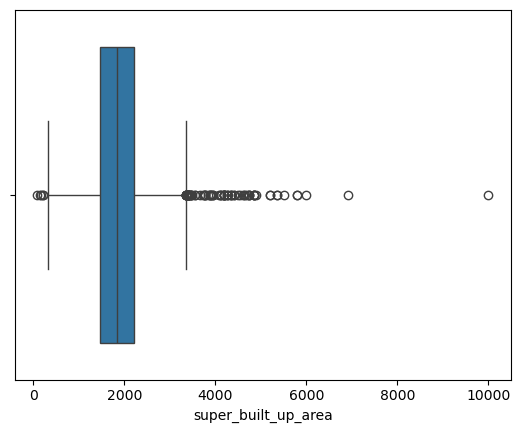

In [111]:
sns.boxplot(x=df['super_built_up_area'])

In [113]:
df['super_built_up_area'].describe()

count     1915.000000
mean      1921.658251
std        767.160169
min         89.000000
25%       1457.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [115]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
155,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49
3700,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,1,140


In [117]:
#built up area

In [119]:
df[df['super_built_up_area'] > 6000]


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
155,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49
3700,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,1,140


In [123]:
#built up area

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

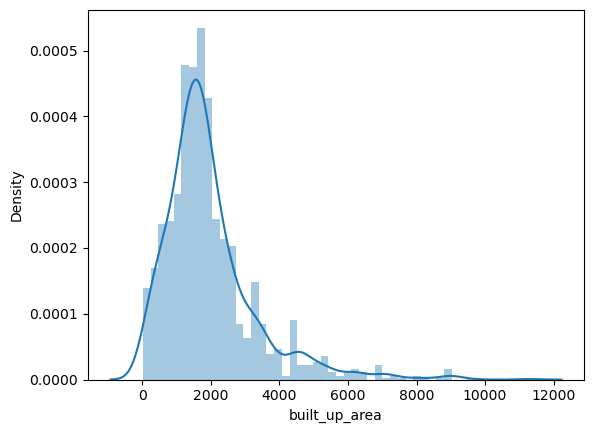

In [125]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

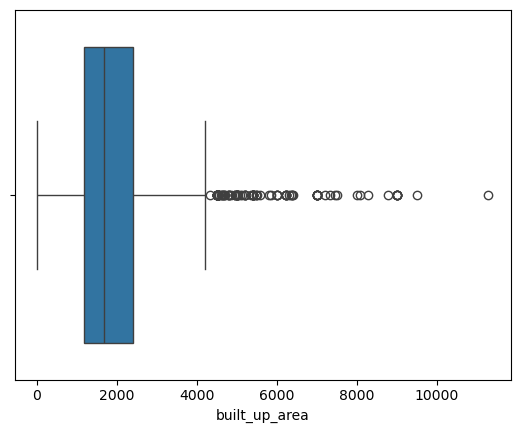

In [127]:
sns.boxplot(x=df['built_up_area'])

In [129]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
281,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,0,0,1,42


In [131]:
#carpet Area


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

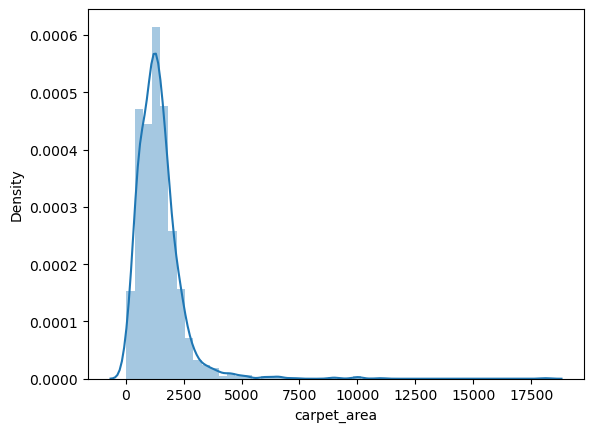

In [133]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

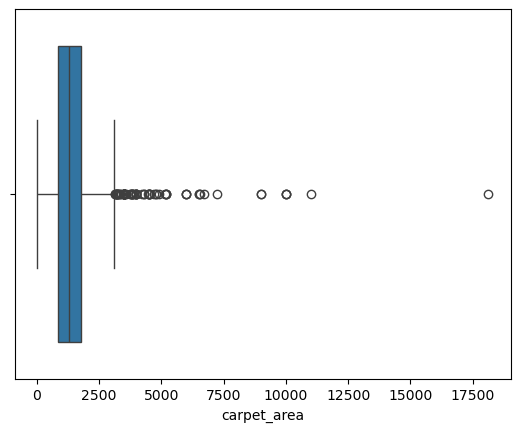

In [135]:
sns.boxplot(x=df['carpet_area'])


In [137]:
df[df['carpet_area'] > 10000]


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1845,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60
2985,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1,0,0,1,1,1,44


In [143]:
df.loc[2985,'carpet_area'] = 1812

In [145]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1845,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60


In [147]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet ar...,3,3,2,6.0,West,Relatively New,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up...,4,6,3+,15.0,East,Relatively New,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,flat,signature global park,sohna road,0.95,7846.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet ar...,3,2,3+,1.0,NaN,Relatively New,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,house,nirvana cedar crest,sector 50,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,4.0,North-East,New Property,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3,3,2,2.0,North-East,Relatively New,1578.0,NaN,NaN,0,0,0,1,0,0,102


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

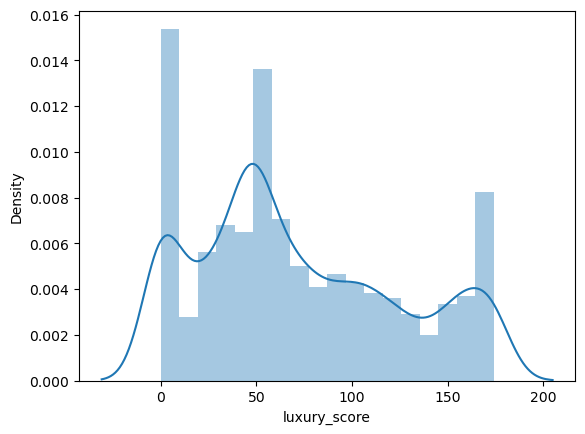

In [149]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

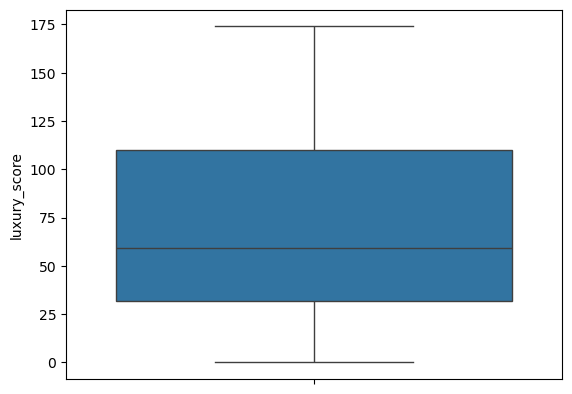

In [151]:
sns.boxplot(df['luxury_score'])

In [153]:
df.shape

(3670, 23)

In [155]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [157]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8025.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet ar...,3,3,2,6.0,West,Relatively New,1620.0,NaN,867.24,1,0,0,1,0,0,151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up...,4,6,3+,15.0,East,Relatively New,4848.0,3655.350000,3500.00,0,1,0,1,0,1,174
2,flat,signature global park,sohna road,0.95,7845.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet ar...,3,2,3+,1.0,NaN,Relatively New,NaN,1210.723472,756.60,0,0,0,0,0,0,46
3,house,nirvana cedar crest,sector 50,3.99,8867.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,4.0,North-East,New Property,NaN,4500.000000,NaN,0,1,0,0,0,1,112
4,flat,tulip violet,sector 69,1.40,8861.0,1580.0,Super Built up area 1578(146.6 sq.m.),3,3,2,2.0,North-East,Relatively New,1578.0,NaN,NaN,0,0,0,1,0,0,102


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9456\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

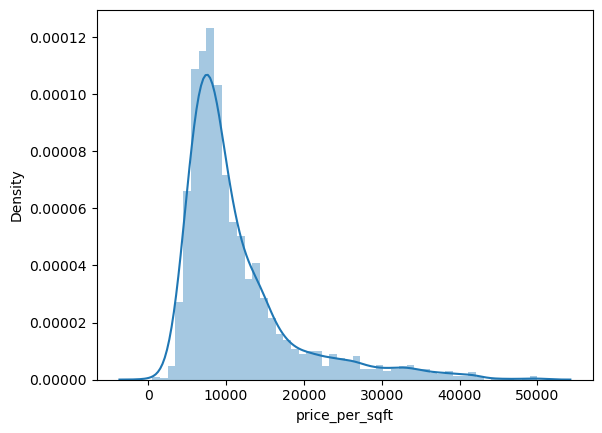

In [159]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

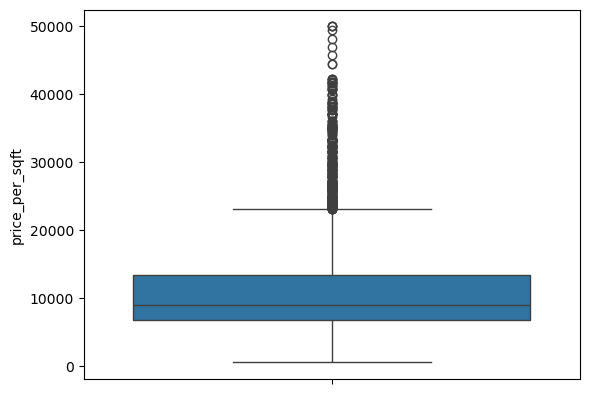

In [161]:
sns.boxplot(df['price_per_sqft'])

In [163]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
130,house,independent,sector 43,9.50,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.000000,0,0,0,0,0,1,88
1064,flat,breez global hill view,sohna road,2.60,46931.0,554.0,Carpet area: 554.16 (51.48 sq.m.),2,2,2,6.0,NaN,New Property,NaN,NaN,554.125572,0,0,0,0,0,0,42
1213,house,independent,sector 26,19.00,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,0,0,0,0,0,1,103
1333,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,0,0,2,97
1396,house,sushant lok 1 builder floors,sector 43,13.00,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,NaN,2700.0,NaN,0,1,0,0,1,1,7
1639,house,independent,sector 28,12.00,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0,0,0,0,0,1,60
2263,house,independent,sector 55,5.00,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.000000,0,1,0,0,0,1,44
2275,house,independent,sector 105,9.90,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,NaN,2000.0,1800.000000,0,0,0,0,1,0,0
2326,house,independent,sector 105,0.50,50000.0,100.0,Built Up area: 100 (9.29 sq.m.),2,2,0,1.0,NaN,Undefined,NaN,100.0,NaN,0,0,0,0,0,0,0
3541,house,independent,sector 25,13.00,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,0,1,0,0,0,2,0


In [169]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

260.0

In [171]:
df[(df['area']/df['bedRoom'])<260]


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
12,house,rattan garden,sector 7,0.83,17585.0,472.0,Carpet area: 472 (43.85 sq.m.),5,3,2,3.0,East,Undefined,NaN,NaN,472.000000,0,0,0,0,0,0,0
21,flat,rof ananda,sector 95,0.38,5901.0,644.0,Carpet area: 644.12 (59.84 sq.m.),3,2,1,2.0,South-East,Relatively New,NaN,NaN,644.111776,0,0,0,1,0,1,66
44,flat,central park flower valley,sector 33,1.40,21538.0,650.0,Super Built up area 650(60.39 sq.m.),3,3,3,2.0,NaN,Under Construction,650.0,NaN,NaN,0,0,0,0,0,0,54
62,house,independent,sector 4,1.10,11111.0,990.0,Built Up area: 990 (91.97 sq.m.),6,4,1,2.0,North,Undefined,NaN,990.0,NaN,1,0,0,0,0,0,0
82,house,independent,sector 8,0.62,11273.0,550.0,Built Up area: 550 (51.1 sq.m.),3,1,0,2.0,NaN,Undefined,NaN,550.0,NaN,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3727,house,dlf city plots phase 2,sector 25,6.50,33592.0,1935.0,Plot area 215(179.77 sq.m.),9,9,3+,3.0,West,Old Property,NaN,1935.0,NaN,0,1,0,0,0,1,142
3746,flat,gls arawali homes,sohna road,0.32,6723.0,476.0,Built Up area: 476 (44.22 sq.m.),2,1,0,0.0,NaN,Undefined,NaN,476.0,NaN,0,0,0,0,0,0,0
3755,house,independent,sector 3 phase 2,0.40,8000.0,500.0,Built Up area: 500 (46.45 sq.m.)Carpet area: 3...,2,1,0,1.0,South,Undefined,NaN,500.0,300.000000,0,0,1,0,0,0,0
3763,house,independent,sector 4,0.50,10482.0,477.0,Built Up area: 53 (44.31 sq.m.),5,3,0,1.0,NaN,Undefined,NaN,53.0,NaN,0,1,0,1,1,0,0


In [173]:
df[df['area']/df['bedRoom']<250].sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1012,house,bhawani enclave,sector 12,0.42,8235.0,510.0,Plot area 565(52.49 sq.m.)Carpet area: 510 sq....,3,3,0,2.0,East,New Property,NaN,NaN,510.0,0,0,0,0,0,0,0
1718,house,independent,sector 8,0.32,7111.0,450.0,Built Up area: 450 (41.81 sq.m.)Carpet area: 3...,2,3,1,1.0,North-East,Relatively New,NaN,450.0,300.0,0,1,0,0,0,0,0
2762,house,independent,sector 7,0.90,10000.0,900.0,Plot area 100(83.61 sq.m.),6,4,3,3.0,North-East,Old Property,NaN,900.0,NaN,0,0,0,0,0,1,44
3323,house,unitech south city,sector 50,5.88,27222.0,2160.0,Plot area 240(200.67 sq.m.),9,9,3+,3.0,East,Relatively New,NaN,2160.0,NaN,0,0,0,0,0,2,128
3206,house,sector 38 rwa,sector 38,1.40,23932.0,585.0,Plot area 65(54.35 sq.m.)Built Up area: 62 sq....,8,8,3,4.0,East,Moderately Old,NaN,62.0,60.0,0,0,0,0,0,1,40


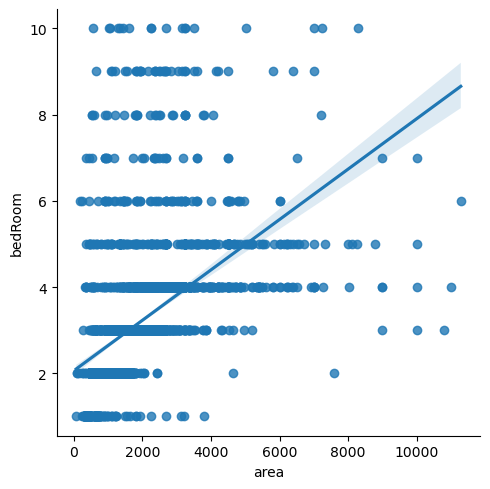

In [177]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [189]:
df['area_room_ratio']=df['area']/df['bedRoom']

In [195]:
(df[df['area_room_ratio']<250])['bedRoom'].value_counts()

bedRoom
2     49
3     37
5     24
4     23
6     19
9     14
8     12
7     10
10     9
1      1
Name: count, dtype: int64

In [199]:
df=df[df['area_room_ratio']>100]

In [218]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room-ratio,area_room_ratio


In [201]:
outliars_df=df[(df['area_room_ratio']<250) & (df['bedRoom']>3)]

In [203]:
outliars_df['bedRoom']=round(outliars_df['bedRoom']/outliars_df['floorNum'])

In [207]:
df.update(outliars_df)

In [216]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room-ratio,area_room_ratio
